# SAMOS pipeline walkthrough — Step04

This notebook documents **Step04** of the SAMOS pipeline: quartz-trace detection and slit-geometry reconstruction.

Step04 is the stage that turns the quartz trace exposure into the **reference geometric model** of the multi-slit mask on the detector. That model is later used for slit identification in science frames, wavelength calibration, slit rectification, and optimal extraction.

The notebook is meant as a practical guide to:

- understand what Step04 does
- run it for `EVEN` and `ODD`
- inspect the main output products
- run the recommended QC scripts
- understand what a good Step04 solution should look like


## 1. Role of Step04 in the pipeline

Step04 operates on **difference images of quartz lamp exposures**:

- `Quartz_B - Quartz_A` for the `EVEN` slit family
- `Quartz_B - Quartz_A` for the `ODD` slit family

The subtraction suppresses diffuse background and highlights the illuminated slit traces. The goal is to derive a stable, detector-based description of each slit footprint while preserving the detector-Y geometry needed later for wavelength calibration.

At a high level, Step04 performs these operations:

1. detect approximate slit centers
2. build a binary slit mask using row-wise segmentation
3. assign slit IDs to the mask pixels
4. derive smooth slit geometry models for center and edges

The main geometric outputs are smooth models of:

- `x_center(y)`
- `x_left(y)`
- `x_right(y)`

These products are then consumed downstream by Step05, Step06, Step07, and Step08.


## Notebook path handling

This notebook may live outside the repo root, for example under `drivers/Jupyter/`. Because of that, all pipeline and QC scripts should be executed through `run_repo_script(...)`, which resolves paths relative to `REPO_ROOT` instead of the notebook working directory.


In [1]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path) -> Path | None:
    candidates = [start] + list(start.parents)
    for p in candidates:
        cfg_dir = p / "config"
        if cfg_dir.is_dir() and (cfg_dir / "__init__.py").exists():
            return p
    return None

# Priority:
# 1) explicit environment variable
# 2) current working directory or one of its parents containing config/__init__.py
repo_env = os.environ.get("SAMOS_REPO_ROOT", "").strip()
if repo_env:
    REPO_ROOT = Path(repo_env).expanduser().resolve()
else:
    REPO_ROOT = find_repo_root(Path.cwd())

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find the SAMOS repository root. "
        "Run this notebook from the samos-pipeline repo root, or set "
        "the environment variable SAMOS_REPO_ROOT to that path."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import config

print('Repo root        :', REPO_ROOT)
print('Step03.5 input   :', config.ST03P5_ROWSTRIPE)
print('Step04 output dir:', config.ST04_TRACES)
print('RADEC EVEN       :', config.RADEC_EVEN_CSV)
print('RADEC ODD        :', config.RADEC_ODD_CSV)
print('Quartz OFF       :', config.QUARTZ_SLITS_OFF)
print('Quartz ON EVEN   :', config.QUARTZ_SLITS_ON_EVEN)
print('Quartz ON ODD    :', config.QUARTZ_SLITS_ON_ODD)


Repo root        : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
Step03.5 input   : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe
Step04 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces
RADEC EVEN       : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/regions/radec_Even.csv
RADEC ODD        : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/regions/radec_Odd.csv
Quartz OFF       : 038.quartz_biascorr_cr_rowcorr

In [2]:
from pathlib import Path
import subprocess
import os
import sys

PYTHON = sys.executable

def run_repo_script(relpath: str, *args, check: bool = True):
    script = REPO_ROOT / relpath
    if not script.exists():
        raise FileNotFoundError(f"Script not found: {script}")

    env = os.environ.copy()
    old_pp = env.get("PYTHONPATH", "")
    env["PYTHONPATH"] = str(REPO_ROOT) + (os.pathsep + old_pp if old_pp else "")

    cmd = [PYTHON, str(script), *map(str, args)]
    print("Running:", " ".join(cmd))
    print("cwd     :", REPO_ROOT)
    print("PYTHONPATH:", env["PYTHONPATH"])

    return subprocess.run(
        cmd,
        check=check,
        cwd=str(REPO_ROOT),
        env=env,
    )

def repo_path(relpath: str) -> Path:
    p = REPO_ROOT / relpath
    print(p)
    return p


## 2. Canonical Step04 commands

### Command line

```bash
PYTHONPATH=. python pipeline/step04_traces/step04_make_traces.py --set EVEN
PYTHONPATH=. python pipeline/step04_traces/step04_make_traces.py --set ODD
```

### Through the batch driver

```bash
PYTHONPATH=. python drivers/run_pipeline.py --from-step 04 --to-step 04 --set ALL
```


In [3]:
# Run Step04 from any notebook location.
# Uncomment the lines you want to execute.

# run_repo_script("pipeline/step04_traces/step04_make_traces.py", "--set", "EVEN")
# run_repo_script("pipeline/step04_traces/step04_make_traces.py", "--set", "ODD")


## 3.1 Conceptual algorithm

Your saved Step04 documentation is especially useful here, because it explains the intended logic cleanly.

### Slit-center detection

The quartz difference image is collapsed into a 1D profile in X. Local maxima in that profile correspond to illuminated slit traces and provide the initial X seeds for the later segmentation.

### Row-wise slit segmentation

For each slit and each detector row, the code inspects a local window around the expected center, estimates background from sidebands, computes a threshold of the form:

`threshold = background + Nσ × local_noise`

and retains the contiguous illuminated region around the trace center. This produces the binary slit mask.

### Slit-ID assignment

Pixels inside the accepted mask are assigned to the nearest slit center, producing the integer slit-ID map used later for identification, geometry measurement, and rectification support.

### Geometry reconstruction

For each slit, the algorithm measures center and edges as functions of detector Y, smooths those measurements, and fits robust low-order polynomials. Conceptually, the slit can be described in terms of center and width, with the left and right edges reconstructed from them. In practice, the exact implementation details should always be checked against the current production script.


## 4. Main Step04 products

For each trace family, Step04 writes a set of products under `config.ST04_TRACES`.

### Core files

- `*_traces.fits` — quartz difference image used for slit detection
- `*_mask.fits` — binary or boolean slit footprint
- `*_slitid.fits` — integer slit assignment map
- `*_slit_table.csv` — per-slit summary table
- `*_geometry.fits` — authoritative downstream geometry reference
- `*_gap_cuts.csv` — per-slit second-order trimming information when enabled

### EVEN example

- `Even_traces.fits`
- `Even_traces_mask.fits`
- `Even_traces_slitid.fits`
- `Even_traces_slit_table.csv`
- `Even_traces_geometry.fits`
- `Even_traces_gap_cuts.csv`

and similarly for the ODD set.

The most important downstream product is the geometry FITS file. Each slit extension typically carries the slit ID, Y coverage, fitted coefficients, RA/Dec association, and fit diagnostics.


In [4]:
from pathlib import Path

st04 = Path(config.ST04_TRACES)
for p in sorted(st04.glob('*')):
    print(p.name)


.DS_Store
Even_traces.fits
Even_traces_gap_cuts.csv
Even_traces_geometry.fits
Even_traces_mask.fits
Even_traces_mask_reg.fits
Even_traces_slit_table.csv
Even_traces_slitid.fits
Even_traces_slitid_reg.fits
Even_traces_traces.reg
Odd_traces.fits
Odd_traces_gap_cuts.csv
Odd_traces_geometry.fits
Odd_traces_mask.fits
Odd_traces_mask_reg.fits
Odd_traces_slit_table.csv
Odd_traces_slitid.fits
Odd_traces_slitid_reg.fits
Odd_traces_traces.reg
qc_compare_old_new_even_gapcuts
qc_step04_diag_even
qc_step04_even
qc_step04_odd


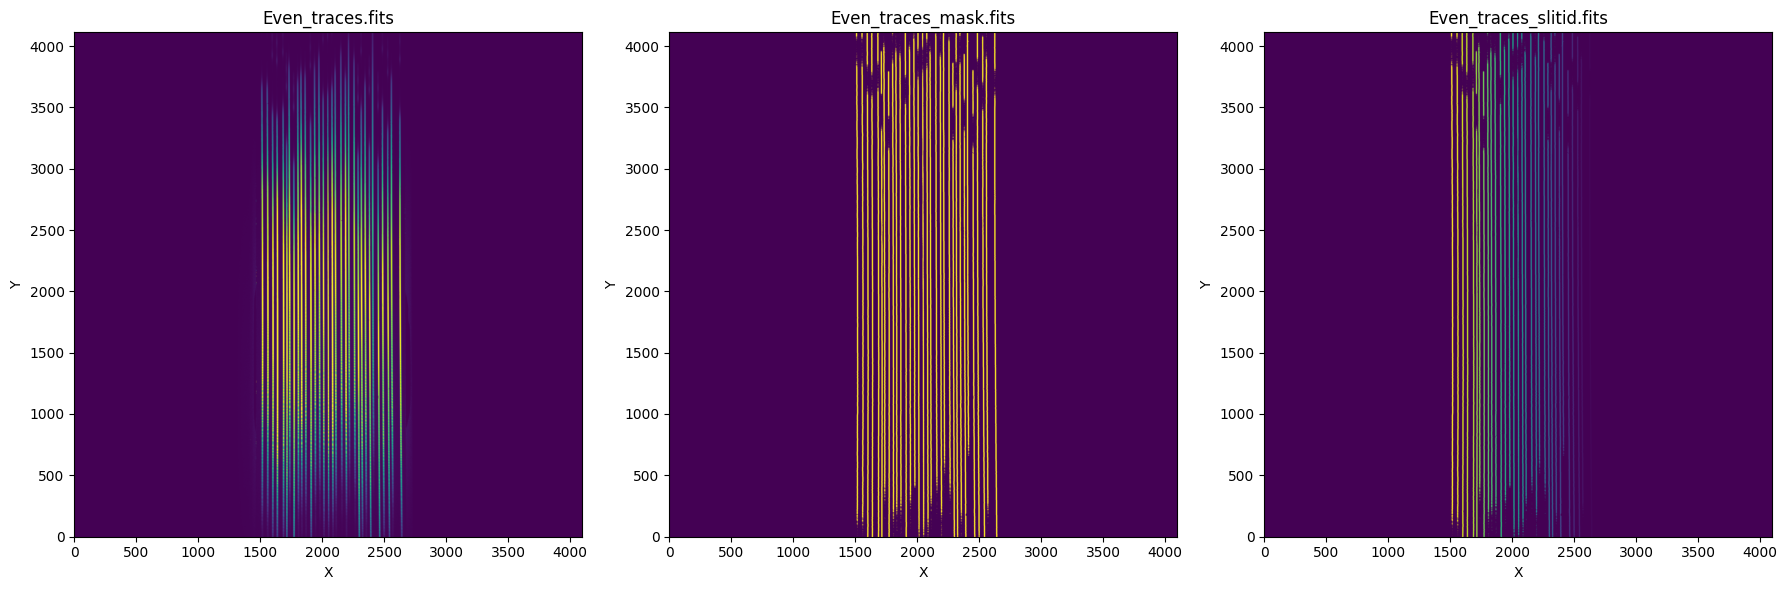

In [5]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

base = 'Even_traces'   # change to 'Odd_traces' for ODD
st04 = Path(config.ST04_TRACES)

img = fits.getdata(st04 / f'{base}.fits')
mask = fits.getdata(st04 / f'{base}_mask.fits')
slitid = fits.getdata(st04 / f'{base}_slitid.fits')

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
vmin = np.nanpercentile(img, 5)
vmax = np.nanpercentile(img, 99)
ax[0].imshow(img, origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
ax[0].set_title(f'{base}.fits')
ax[1].imshow(mask, origin='lower', aspect='auto')
ax[1].set_title(f'{base}_mask.fits')
ax[2].imshow(slitid, origin='lower', aspect='auto')
ax[2].set_title(f'{base}_slitid.fits')
for a in ax:
    a.set_xlabel('X')
    a.set_ylabel('Y')
plt.tight_layout()


> **Implementation note**
>
> The prose in this notebook follows the saved Step04 design note, which describes the intended algorithm clearly. For any command, filename, keyword, or fit detail, the current production script and config remain the source of truth.


## 5. Inspect the geometry FITS product

The geometry file is the key downstream product. Each slit is typically stored in an extension with header keywords describing the polynomial coefficients for the center and edges.


In [6]:
from astropy.io import fits
from pathlib import Path

geom_path = Path(config.ST04_TRACES) / 'Even_traces_geometry.fits'
with fits.open(geom_path) as hdul:
    print('N HDUs =', len(hdul))
    for h in hdul[:6]:
        print(h.name)
    if len(hdul) > 1:
        hdr = hdul[1].header
        for k in ['EXTNAME', 'SLITID', 'YMIN', 'YMAX', 'XREF', 'PORDER', 'EPORDER', 'RMSC', 'RMSL', 'RMSR']:
            if k in hdr:
                print(f'{k:8s} = {hdr[k]}')


N HDUs = 33
PRIMARY
SLIT062
SLIT060
SLIT058
SLIT056
SLIT054
EXTNAME  = SLIT062
SLITID   = 62
YMIN     = 12
YMAX     = 4111
XREF     = 1518.302622359939
PORDER   = 2
EPORDER  = 2
RMSC     = 0.8542282867877666
RMSL     = 1.180992096813714
RMSR     = 1.4782057515477514


## 6. Recommended QC sequence

1. **Trace quicklooks** for an immediate full-frame and per-slit view
2. **Physical geometry validation** for row-by-row residuals and fragmentation
3. **Single-slit diagnosis** only if a specific slit looks wrong


In [7]:
# Run the canonical Step04 QC scripts from any notebook location.
# Uncomment the commands you want to execute.

# run_repo_script("qc/step04/qc_step04_trace_quicklooks.py", "--traceset", "EVEN")
# run_repo_script("qc/step04/qc_step04_trace_quicklooks.py", "--traceset", "ODD")
# run_repo_script("qc/step04/qc_step04_physical_geometry_validation.py")
# run_repo_script("qc/step04/qc_step04_trace_diagnose_single.py", "--traceset", "EVEN", "--slit", "SLIT018")


## QC visualization: slit montage

The quicklook QC produces montage images for each trace set. These are the most immediate way to verify that the fitted geometry follows the quartz traces correctly.

Typical filenames:

- `even_slit_montage.jpg`
- `odd_slit_montage.jpg`

Below we attempt to display them if present.


Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/qc_step04_even/even_slit_montage.jpg


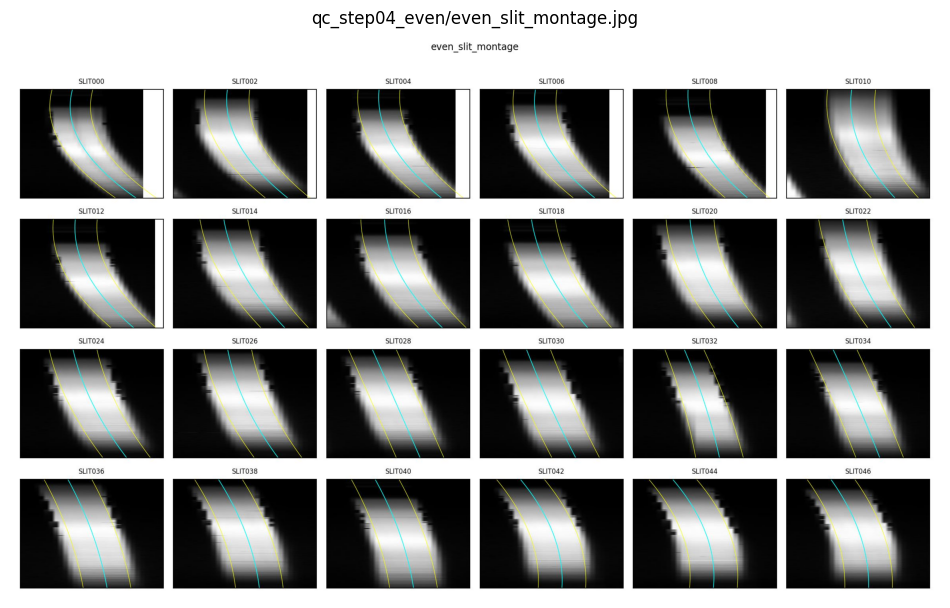

Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/qc_step04_odd/odd_slit_montage.jpg


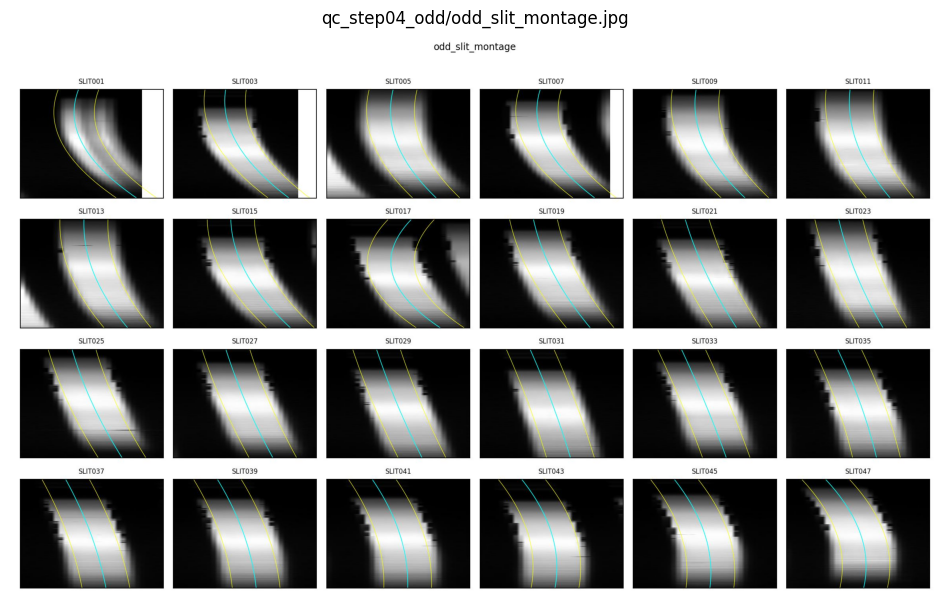

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import config

st04 = Path(config.ST04_TRACES)

candidates = [
    st04 / "qc_step04_even" / "even_slit_montage.jpg",
    st04 / "qc_step04_odd" / "odd_slit_montage.jpg",
    st04 / "even_slit_montage.jpg",
    st04 / "odd_slit_montage.jpg",
]

for p in candidates:
    if p.exists():
        print("Displaying:", p)
        img = Image.open(p)
        plt.figure(figsize=(12, 12))
        plt.imshow(img)
        plt.axis("off")
        plt.title(str(p.relative_to(st04)))
        plt.show()

## 7. What a good Step04 solution should look like

A successful Step04 should show:

- all expected slits detected
- slit ordering consistent with RA ordering
- masks that hug the illuminated ridge without bloating
- smooth center and edge fits
- low row-by-row fragmentation
- sensible gap cuts where second order is present
